# Interactive Integrate-and-Fire Demo

A real-domain integrate-and-fire network with Erdos-Renyi connections. Two things this
notebook shows:

1. **Getting a spike train out.** Threshold reset and spike events are handled by a
   solver callback, so spike times are root-found (exact) rather than read off the
   saved trajectory.
2. **Swapping the input spike kernel.** The same input spike train is convolved with a
   narrow delta-like impulse and with a very wide Gaussian. Both kernels carry unit
   area, so widening smears the same total charge over more time rather than also
   turning up the drive.

In [1]:
using Pkg
Pkg.activate("/home/wilkie/code/SpikingNetworks.jl")
using SpikingNetworks, Plots
using Random: Xoshiro

  Activating project at `~/code/SpikingNetworks.jl`


## Define the neuron model

In [2]:
n_neurons = 20
t_span = (0.0f0, 5.0f0)
dt = 0.005f0

0.005f0

Integrate-and-fire neurons wired into an Erdos-Renyi random graph.

In [3]:
model = IntegrateAndFire(n_neurons, 0.15f0; threshold=0.15f0, seed=Xoshiro(42))
println("Connection density: ", sum(model.W .!= 0) / length(model.W))
println("Leakage lambda: ", model.lambda)
println("Threshold: ", model.threshold, ", rest: ", model.rest)

Connection density: 0.16
Leakage lambda: -0.2
Threshold: 0.15, rest: 0.0


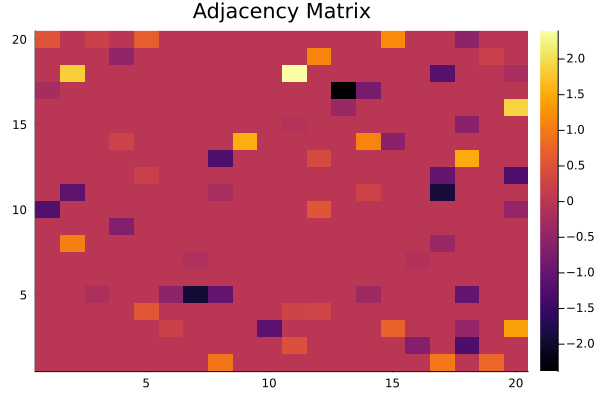

In [4]:
heatmap(model.W)
title!("Adjacency Matrix")

## The input: one spike train, reused everywhere

Sample the Poisson source **once** into a `SpikeTrain`. This matters: if the input were
drawn fresh inside the ODE right-hand side, the solver would see a different vector field
at every Runge-Kutta stage, runs would not reproduce, and root-finding the threshold
crossings would be meaningless.

Spike Train: (20,) with 490 spikes.


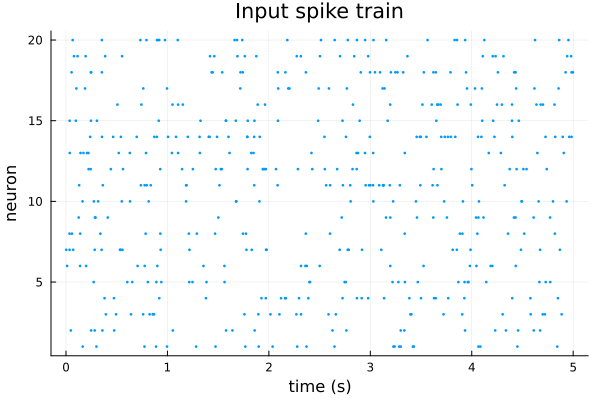

In [5]:
input_gen = CurrentGenerator(5.0f0, 0.001f0, n_neurons, Xoshiro(7))
input_train = poisson_spike_train(input_gen, t_span)
println(input_train)

scatter(input_train.times, getindex.(input_train.indices, 1);
        markersize=1.5, markerstrokewidth=0, legend=false,
        xlabel="time (s)", ylabel="neuron", title="Input spike train")

## Substituting a spike kernel

A `SpikeKernel` is the shape of the current one input spike injects. It is callable on a
time offset and reports its own truncation radius via `support`, so `spike_current` never
has to guess how wide it is.

Below: a `DeltaKernel` a few solver steps wide (a kernel narrower than `dt` can be stepped
straight over) against a `GaussianKernel` roughly 50x wider. Both are area-normalised, so
they differ in *shape*, not in total charge.

delta:    peak 50.0, support +/- 0.01
gaussian: peak 1.5957692, support +/- 1.0


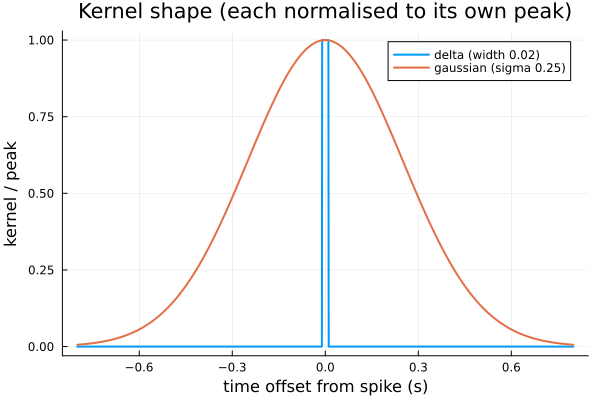

In [6]:
delta_k = DeltaKernel(0.02f0)      # short, impulse-like
gauss_k = GaussianKernel(0.25f0)   # very wide

println("delta:    peak ", delta_k(0.0f0), ", support +/- ", support(delta_k))
println("gaussian: peak ", gauss_k(0.0f0), ", support +/- ", support(gauss_k))

# Plot each kernel scaled to its own peak so the comparison is purely about width
offsets = -0.8f0:0.001f0:0.8f0
plot(offsets, [delta_k(x) / delta_k(0.0f0) for x in offsets];
     label="delta (width 0.02)", lw=2)
plot!(offsets, [gauss_k(x) / gauss_k(0.0f0) for x in offsets];
      label="gaussian (sigma 0.25)", lw=2)
xlabel!("time offset from spike (s)"); ylabel!("kernel / peak")
title!("Kernel shape (each normalised to its own peak)")

Convolving the same input train with each kernel gives the injected current:

delta    current: mean 2.5337162, peak 75.0
gaussian current: mean 2.335779, peak 8.733928


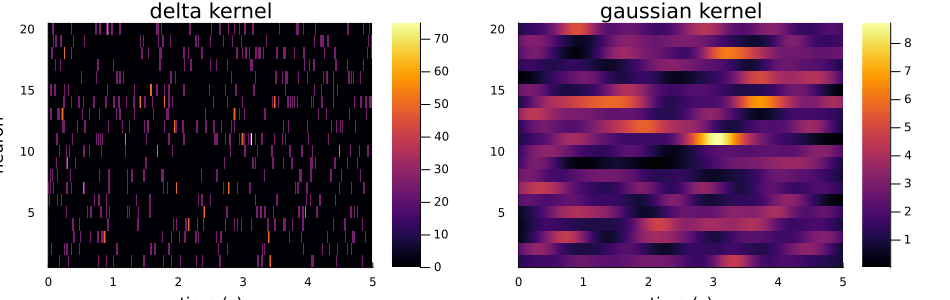

In [7]:
grid = collect(t_span[1]:dt:t_span[2])

function current_grid(kernel; scale=0.5f0)
    args = SpikingArgs(spike_kernel=kernel, spk_scale=scale,
                       solver_args=Dict(:dt => dt, :adaptive => false))
    I_fn = t -> spike_current(input_train, t, args)
    return stack([I_fn(t) for t in grid], dims=2), I_fn, args
end

I_delta, _, _ = current_grid(delta_k)
I_gauss, _, _ = current_grid(gauss_k)

println("delta    current: mean ", sum(I_delta)/length(I_delta), ", peak ", maximum(I_delta))
println("gaussian current: mean ", sum(I_gauss)/length(I_gauss), ", peak ", maximum(I_gauss))

plot(heatmap(grid, 1:n_neurons, I_delta; title="delta kernel", xlabel="time (s)", ylabel="neuron"),
     heatmap(grid, 1:n_neurons, I_gauss; title="gaussian kernel", xlabel="time (s)"),
     layout=(1,2), size=(950, 300))

Same mean current, very different peak: the Gaussian spreads each spike's charge over
about a second instead of 20 ms.

## Simulate

`reset_callback` returns a `VectorContinuousCallback` plus a recorder. The callback
root-finds upward crossings of `model.threshold`, drives that neuron back to `model.rest`
through `integrator.u`, and logs the exact event time. The update equation stays a pure
function of `(z, t)` — writing to `z` inside it would corrupt the solver's stage vectors.

In [8]:
z0 = zeros(Float32, n_neurons)

function run_kernel(kernel; scale=0.5f0, reset=true)
    args = SpikingArgs(spike_kernel=kernel, spk_scale=scale,
                       solver_args=Dict(:dt => dt, :adaptive => false))
    I_fn = t -> spike_current(input_train, t, args)
    if reset
        cb, rec = reset_callback(model)
        sol = simulate_network(model, z0, I_fn, t_span; spike_args=args, callback=cb)
        return sol, SpikeTrain(rec, (n_neurons,))
    else
        return simulate_network(model, z0, I_fn, t_span; spike_args=args), nothing
    end
end

run_kernel (generic function with 1 method)

In [9]:
sol_d, out_d = run_kernel(delta_k)
sol_g, out_g = run_kernel(gauss_k)

for (name, sol, out) in [("delta", sol_d, out_d), ("gaussian", sol_g, out_g)]
    u = stack(sol.u, dims=2)
    println(name, ": ", length(sol.t), " time points, peak potential ", maximum(u),
            " (threshold ", model.threshold, ")")
    println("   output ", out)
end

delta: 3230 time points, peak potential 0.15068623 (threshold 0.15)
   output Spike Train: (20,) with 1369 spikes.
gaussian: 3049 time points, peak potential 0.15 (threshold 0.15)
   output Spike Train: (20,) with 1289 spikes.


Non-empty spike trains, and the peak potential sits right at the threshold — the callback
reset is genuinely holding the state down, which the old in-right-hand-side mutation could
not guarantee.

### Membrane potentials

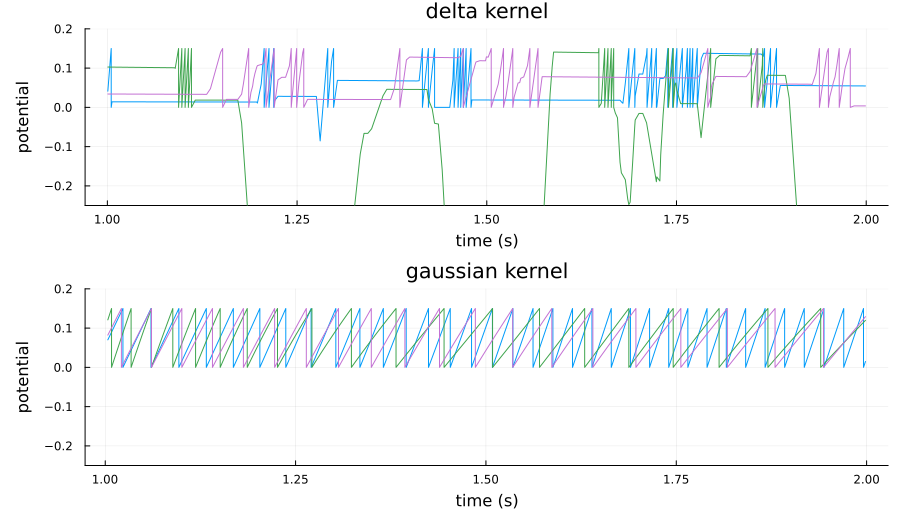

In [10]:
using Plots.PlotMeasures

# Zoom to four neurons over one second: over the full 5 s the ~1300 resets pile up
# into a solid band and nothing is legible.
show_neurons = 1:4
window = (1.0f0, 2.0f0)

function trace_panel(sol, title)
    keep = findall(t -> window[1] <= t <= window[2], sol.t)
    u = stack(sol.u, dims=2)[show_neurons, keep]
    plot(sol.t[keep], u'; legend=false, title=title, lw=1,
         xlabel="time (s)", ylabel="potential", ylims=(-0.25, 0.2))
end

plot(trace_panel(sol_d, "delta kernel"), trace_panel(sol_g, "gaussian kernel"),
     layout=(2,1), size=(900, 520), left_margin=6mm, bottom_margin=4mm)

### Output spike rasters

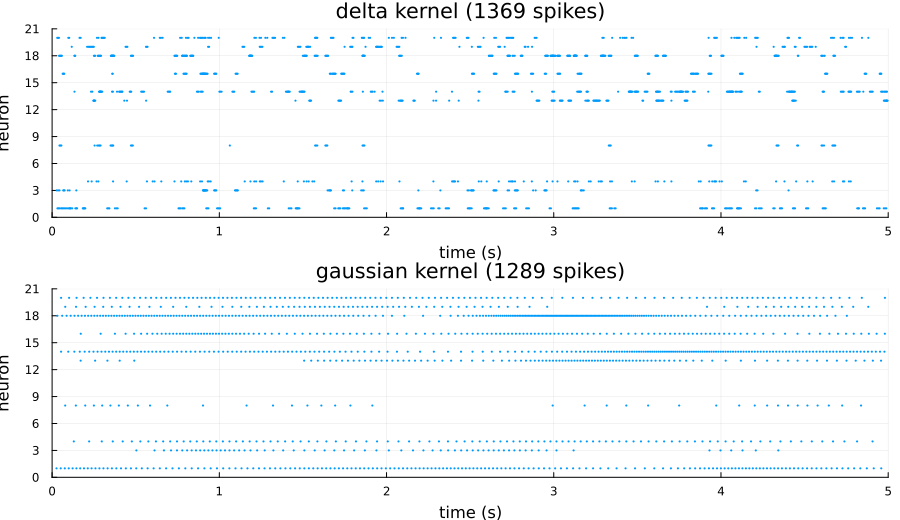

In [11]:
function raster(train, title)
    scatter(train.times, getindex.(train.indices, 1);
            markersize=1.2, markerstrokewidth=0, legend=false,
            xlabel="time (s)", ylabel="neuron", title=title,
            xlims=(t_span[1], t_span[2]), ylims=(0, n_neurons + 1))
end

plot(raster(out_d, "delta kernel ($(length(out_d)) spikes)"),
     raster(out_g, "gaussian kernel ($(length(out_g)) spikes)"),
     layout=(2,1), size=(900, 520))

## Cross-check: `find_spikes_ref`

`find_spikes_ref` is the reference detector — local maxima of the trajectory above
threshold. It is the right tool for a model with **no** reset. With the reset active every
peak is clipped exactly *at* threshold, so a strict `> threshold` test cannot fire; there
the callback is the spike source, not the detector.

Re-run without the callback so the potentials free-run, and the detector has real peaks to
find.

In [12]:
for (name, kernel) in [("delta", delta_k), ("gaussian", gauss_k)]
    sol_free, _ = run_kernel(kernel; reset=false)
    u_free = stack(sol_free.u, dims=2)
    channels, times = find_spikes_ref(u_free, sol_free.t, model.threshold; dim=2)
    println(name, ": free-running peak ", round(maximum(u_free), digits=2),
            ", find_spikes_ref found ", length(times), " peaks above threshold")
end

delta: free-running peak 26.84, find_spikes_ref found 460 peaks above threshold
gaussian: free-running peak 25.14, find_spikes_ref found 16 peaks above threshold


## Summary

- The input train, the network and the solver are all deterministic — rerun this notebook
  and you get identical spike times.
- With unit-area kernels, widening the Gaussian leaves total charge and overall firing rate
  roughly unchanged, but smooths the potential trajectory and spreads each input spike's
  influence over ~1 s.
- Any callable with a `support` can be dropped in: `DeltaKernel`, `GaussianKernel`,
  `RaisedCosineKernel`, `AlphaKernel`, or `FunctionKernel(f, radius)` for something custom.